# 05 — ResNet50 Transfer Learning: Vehicle Damage Classification

Completed and cleaned version of the modelling notebook. An ImageNet-pretrained ResNet50 is adapted to the binary damage task in two stages:

1. **Frozen backbone** — train only the new single-logit head so the pretrained features are reused as-is.
2. **Fine-tuning** — unfreeze the top residual block (`layer4`) at a smaller learning rate.

The output is `resnet50_best.pth` (a `Linear(2048, 1)` head) and a set of validation metrics/predictions consumed by notebooks 07 and 08. Everything is kept on the same 80/20 stratified split as the baseline CNN so the comparison is like-for-like.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
DATA_DIR = Path("c:\\Users\\Niraj Mhatre\\projects\\motor_insurance_data\\Fast_Furious_Insured")

TRAIN_IMG_DIR = DATA_DIR / "trainImages"
TRAIN_METADATA = DATA_DIR / "processed" / "train_metadata_clean.csv"

MODEL_DIR = Path("../models")
TABLE_DIR = Path("../outputs/tables")
PRED_DIR = Path("../outputs/predictions")

for d in (MODEL_DIR, TABLE_DIR, PRED_DIR):
    d.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(TRAIN_METADATA)
print(df.shape)
df.head()

(1399, 8)


,Image_path,Insurance_company,Cost_of_vehicle,Min_coverage,Expiry_date,Max_coverage,Condition,Amount
0,img_4513976.jpg,BQ,41500.0,1037.5,2026-12-03,36142.68,0,0.0
1,img_7764995.jpg,BQ,50700.0,1267.5,2025-07-10,12753.00,1,6194.0
2,img_451308.jpg,A,49500.0,1237.5,2022-08-11,43102.68,0,0.0
3,img_7768372.jpg,A,33500.0,837.5,2022-08-02,8453.00,1,7699.0
4,img_7765274.jpg,AC,27600.0,690.0,2026-05-01,6978.00,1,8849.0


In [4]:
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["Condition"],
)

print("Train:", train_df.shape, "| Validation:", val_df.shape)
print("\nTraining distribution:")
print(train_df["Condition"].value_counts(normalize=True))
print("\nValidation distribution:")
print(val_df["Condition"].value_counts(normalize=True))

Train: (1119, 8) | Validation: (280, 8)

Training distribution:
Condition
1    0.929401
0    0.070599
Name: proportion, dtype: float64

Validation distribution:
Condition
1    0.928571
0    0.071429
Name: proportion, dtype: float64


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.03),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [6]:
class VehicleDamageDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(self.image_dir / row["Image_path"]).convert("RGB")
        label = torch.tensor(row["Condition"], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, label

In [7]:
BATCH_SIZE = 32

train_dataset = VehicleDamageDataset(train_df, TRAIN_IMG_DIR, train_transform)
val_dataset = VehicleDamageDataset(val_df, TRAIN_IMG_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

In [8]:
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)
model = model.to(device)

In [9]:
num_negative = (train_df["Condition"] == 0).sum()
num_positive = (train_df["Condition"] == 1).sum()

pos_weight = torch.tensor([num_negative / num_positive], dtype=torch.float32).to(device)
print("Positive class weight:", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

Positive class weight: 0.07596153765916824


In [10]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_labels, all_probs = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            running_loss += criterion(outputs, labels).item() * images.size(0)

            probs = torch.sigmoid(outputs)
            all_probs.extend(probs.cpu().numpy().ravel())
            all_labels.extend(labels.cpu().numpy().ravel())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    preds = (all_probs >= 0.5).astype(int)

    return {
        "loss": running_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_labels, preds),
        "precision": precision_score(all_labels, preds, zero_division=0),
        "recall": recall_score(all_labels, preds, zero_division=0),
        "f1": f1_score(all_labels, preds, zero_division=0),
        "auc": roc_auc_score(all_labels, all_probs),
        "pr_auc": average_precision_score(all_labels, all_probs),
        "probs": all_probs,
        "labels": all_labels,
    }

## Stage 1 — frozen backbone

Freeze every pretrained parameter and train only the new head. This calibrates the classifier to the vehicle-damage distribution without disturbing the ImageNet features.

In [11]:
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

STAGE1_EPOCHS = 4
history = []
best_f1 = 0.0

for epoch in range(STAGE1_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    m = evaluate(model, val_loader, criterion)
    scheduler.step(m["f1"])

    print(
        f"[stage1] Epoch {epoch+1}/{STAGE1_EPOCHS} | train {train_loss:.4f} | "
        f"val {m['loss']:.4f} | F1 {m['f1']:.4f} | AUC {m['auc']:.4f}"
    )
    history.append({"stage": 1, "epoch": epoch + 1, "train_loss": train_loss,
                    "val_loss": m["loss"], "f1": m["f1"], "precision": m["precision"],
                    "recall": m["recall"], "auc": m["auc"], "pr_auc": m["pr_auc"]})

    if m["f1"] > best_f1:
        best_f1 = m["f1"]
        torch.save(model.state_dict(), MODEL_DIR / "resnet50_best.pth")
        print("  -> best model saved")

c:\Users\Niraj Mhatre\projects\Motor-Insurance-Claim-Severity-Assessment\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[stage1] Epoch 1/4 | train 0.0911 | val 0.0865 | F1 0.7731 | AUC 0.7806
  -> best model saved


c:\Users\Niraj Mhatre\projects\Motor-Insurance-Claim-Severity-Assessment\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[stage1] Epoch 2/4 | train 0.0740 | val 0.0824 | F1 0.7692 | AUC 0.7963


c:\Users\Niraj Mhatre\projects\Motor-Insurance-Claim-Severity-Assessment\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[stage1] Epoch 3/4 | train 0.0666 | val 0.0805 | F1 0.7506 | AUC 0.8052


c:\Users\Niraj Mhatre\projects\Motor-Insurance-Claim-Severity-Assessment\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[stage1] Epoch 4/4 | train 0.0624 | val 0.0802 | F1 0.7767 | AUC 0.8006
  -> best model saved


## Stage 2 — fine-tuning the top residual block

Unfreeze `layer4` (and keep the head trainable) at a much smaller learning rate. The lower blocks — generic edges and textures — stay fixed, which is the standard guard against overfitting a deep network on a modest dataset.

In [12]:
for name, param in model.named_parameters():
    param.requires_grad = name.startswith("layer4") or name.startswith("fc")

trainable = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(trainable, lr=3e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

STAGE2_EPOCHS = 12

for epoch in range(STAGE2_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    m = evaluate(model, val_loader, criterion)
    scheduler.step(m["f1"])

    print(
        f"[stage2] Epoch {epoch+1}/{STAGE2_EPOCHS} | train {train_loss:.4f} | "
        f"val {m['loss']:.4f} | F1 {m['f1']:.4f} | P {m['precision']:.4f} | "
        f"R {m['recall']:.4f} | AUC {m['auc']:.4f}"
    )
    history.append({"stage": 2, "epoch": epoch + 1, "train_loss": train_loss,
                    "val_loss": m["loss"], "f1": m["f1"], "precision": m["precision"],
                    "recall": m["recall"], "auc": m["auc"], "pr_auc": m["pr_auc"]})

    if m["f1"] > best_f1:
        best_f1 = m["f1"]
        torch.save(model.state_dict(), MODEL_DIR / "resnet50_best.pth")
        print("  -> best model saved")

print("\nBest validation F1:", round(best_f1, 4))

c:\Users\Niraj Mhatre\projects\Motor-Insurance-Claim-Severity-Assessment\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[stage2] Epoch 1/12 | train 0.0598 | val 0.0731 | F1 0.8534 | P 0.9706 | R 0.7615 | AUC 0.8290
  -> best model saved


c:\Users\Niraj Mhatre\projects\Motor-Insurance-Claim-Severity-Assessment\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[stage2] Epoch 2/12 | train 0.0508 | val 0.0716 | F1 0.8428 | P 0.9747 | R 0.7423 | AUC 0.8388


c:\Users\Niraj Mhatre\projects\Motor-Insurance-Claim-Severity-Assessment\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

[stage2] Epoch 10/12 | train 0.0154 | val 0.0721 | F1 0.9526 | P 0.9797 | R 0.9269 | AUC 0.8777
  -> best model saved


c:\Users\Niraj Mhatre\projects\Motor-Insurance-Claim-Severity-Assessment\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[stage2] Epoch 11/12 | train 0.0165 | val 0.0741 | F1 0.9463 | P 0.9794 | R 0.9154 | AUC 0.8665


c:\Users\Niraj Mhatre\projects\Motor-Insurance-Claim-Severity-Assessment\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[stage2] Epoch 12/12 | train 0.0147 | val 0.0791 | F1 0.9505 | P 0.9796 | R 0.9231 | AUC 0.8688

Best validation F1: 0.9526


## Learning curves

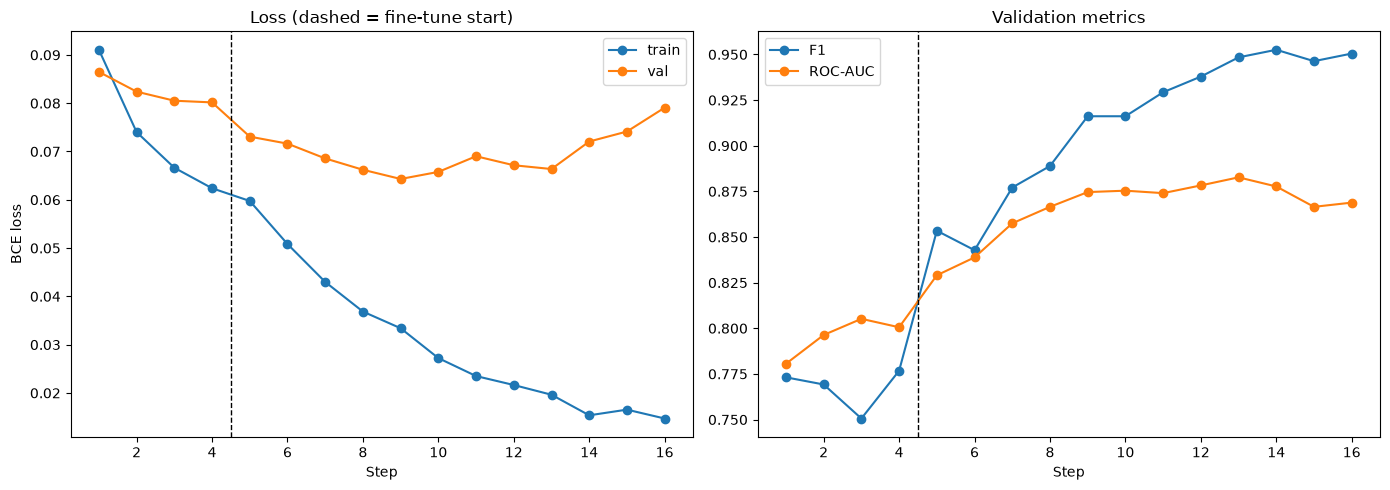

In [13]:
hist = pd.DataFrame(history).reset_index(drop=True)
hist["step"] = np.arange(1, len(hist) + 1)
split = (hist["stage"] == 1).sum()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(hist["step"], hist["train_loss"], marker="o", label="train")
ax[0].plot(hist["step"], hist["val_loss"], marker="o", label="val")
ax[0].axvline(split + 0.5, color="k", ls="--", lw=1)
ax[0].set_xlabel("Step"); ax[0].set_ylabel("BCE loss"); ax[0].set_title("Loss (dashed = fine-tune start)")
ax[0].legend()

ax[1].plot(hist["step"], hist["f1"], marker="o", label="F1")
ax[1].plot(hist["step"], hist["auc"], marker="o", label="ROC-AUC")
ax[1].axvline(split + 0.5, color="k", ls="--", lw=1)
ax[1].set_xlabel("Step"); ax[1].set_title("Validation metrics")
ax[1].legend()

plt.tight_layout()
plt.show()

## Final evaluation

In [14]:
model.load_state_dict(torch.load(MODEL_DIR / "resnet50_best.pth", map_location=device))
final = evaluate(model, val_loader, criterion)

print(classification_report(final["labels"], (final["probs"] >= 0.5).astype(int), digits=4))

c:\Users\Niraj Mhatre\projects\Motor-Insurance-Claim-Severity-Assessment\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

         0.0     0.4412    0.7500    0.5556        20
         1.0     0.9797    0.9269    0.9526       260

    accuracy                         0.9143       280
   macro avg     0.7104    0.8385    0.7541       280
weighted avg     0.9412    0.9143    0.9242       280



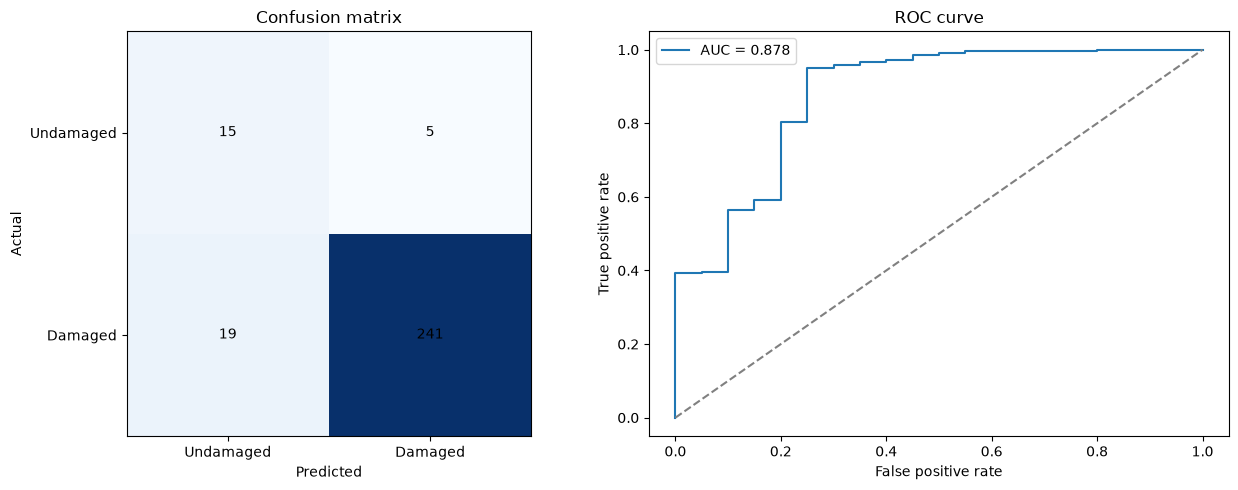

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(final["labels"], (final["probs"] >= 0.5).astype(int))
im = ax[0].imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax[0].text(j, i, str(v), ha="center", va="center")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["Undamaged", "Damaged"])
ax[0].set_yticks([0, 1]); ax[0].set_yticklabels(["Undamaged", "Damaged"])
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual"); ax[0].set_title("Confusion matrix")

fpr, tpr, _ = roc_curve(final["labels"], final["probs"])
ax[1].plot(fpr, tpr, label=f"AUC = {final['auc']:.3f}")
ax[1].plot([0, 1], [0, 1], ls="--", color="grey")
ax[1].set_xlabel("False positive rate"); ax[1].set_ylabel("True positive rate")
ax[1].set_title("ROC curve"); ax[1].legend()

plt.tight_layout()
plt.show()

## Operating threshold

We record the F1-optimal threshold. In deployment the cut-off would instead be tuned to the asymmetric cost of missing a damaged vehicle versus flagging an intact one, but F1 is a reasonable default when that cost matrix is unknown.

In [16]:
prec, rec, thr = precision_recall_curve(final["labels"], final["probs"])
f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = int(np.nanargmax(f1_curve[:-1]))
best_threshold = float(thr[best_idx])
print("F1-optimal threshold:", round(best_threshold, 4))

F1-optimal threshold: 0.0275


In [17]:
metrics_row = pd.DataFrame([{
    "model": "ResNet50",
    "accuracy": final["accuracy"],
    "precision": final["precision"],
    "recall": final["recall"],
    "f1": final["f1"],
    "roc_auc": final["auc"],
    "pr_auc": final["pr_auc"],
    "best_threshold": best_threshold,
}])
metrics_row.to_csv(TABLE_DIR / "resnet50_val_metrics.csv", index=False)

val_out = val_df.reset_index(drop=True).copy()
val_out["cnn_damage_prob"] = final["probs"]
val_out[["Image_path", "Condition", "cnn_damage_prob"]].to_csv(
    PRED_DIR / "resnet50_val_preds.csv", index=False
)

metrics_row

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,best_threshold
0,ResNet50,0.914286,0.979675,0.926923,0.952569,0.877692,0.987351,0.02747


`resnet50_best.pth` and the saved probabilities are the visual signal carried forward. Notebook 07 turns `cnn_damage_prob` into a regression feature and tests whether it improves claim-amount prediction beyond the tabular variables alone.